# 线性神经网络

## 矢量化加速

**⽮量化代码通常会带来数量级的加速。**

In [3]:
%matplotlib inline
import math
import time
import numpy as np
import torch

In [7]:
class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [ ]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

c = torch.zeros([n])

'0.06429 sec'

In [9]:
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]

f'{timer.stop():.5f} sec'

'0.06293 sec'

In [10]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00010 sec'

## 正态分布与平方损失

**均⽅误差损失函数（简称均⽅损失）可以⽤于线性回归**

In [13]:
import matplotlib.pyplot as plt

In [14]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

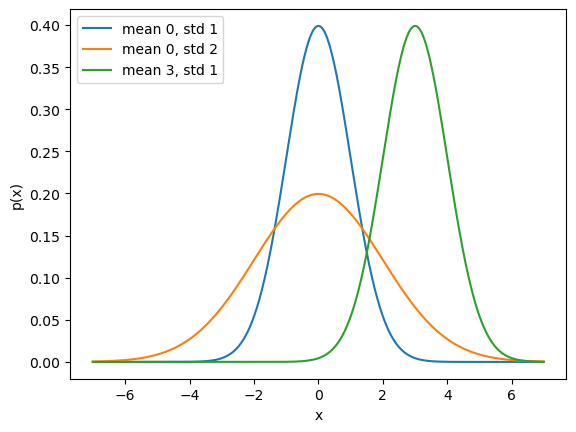

In [17]:
x = np.arange(-7, 7, 0.01)

# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
[plt.plot(x, normal(x, mu, sigma), label=f'mean {mu}, std {sigma}') for mu, sigma in params]

plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()